<div align='center'>
<h1 style='font-size:40px;'>Using the <code>Star</code> Object</h1>
<h2 style='font-weight:400;'>Spectral data, normalization, and stellar properties</h2>
<p><em>Quick guide to stellar spectra handling in pyGrater</em></p>
</div>

---
**This tutorial covers:**
- Initializing a Star
- Accessing physical properties
- Plotting the normalized spectrum
- Resampling or restricting wavelength coverage
- Estimating luminosity
- Re-normalizing with custom wavelength ranges

## 1. Imports

In [1]:
from pyGrater import stargrains as stgr
import matplotlib.pyplot as plt
import numpy as np

## 2. Instantiate a Star
The constructor loads basic properties (distance, temperature, radius, etc.) and fetches the closest synthetic spectrum (NextGen).
Normalization is done using the star's apparent magnitude and filter band listed in the data file.

In [4]:
star = stgr.Star(star_name='bPic')  # Example star
print('Distance [pc]:', star.distance)
print('Teff [K]:', star.temp)
print('Radius [Rsun]:', star.radius)
print('log g:', star.logg)
print('Band normalized:', star.normband)
print('Apparent magnitude:', star.apmag)
print('Wavelength array size:', star.waves.size)

CREATING STAR OBJECT
Star properties file: /Users/prioletp/PhD/public_codes/pyGrater/data/star_data/stars_main_properties.txt
Star name: 'bPic'
The temperature is 8200.0 K
The logg is 4.20 cgs
The radius is 1.76 R_sun
The distance is 19.44 pc
The spectral type is A6
The normalization band is V
The apparent magnitude in V band is 3.86 mag
Closest temperatures in the grid: [[8.2e+03 3.5e+00]
 [8.2e+03 4.0e+00]
 [8.2e+03 4.5e+00]
 [8.2e+03 5.0e+00]
 [8.2e+03 5.5e+00]]
Closest log(g) in the grid: [[8.2e+03 4.0e+00]]
Stellar luminosity: 9.45 m2 L_sun
Stellar spectrum loaded from 0.0099999997 to 3916.7371834 µm and normalized.
Normalized in V-band to 3.86 mag
The stellar luminosity is 9.45 m2 L_sun
Distance [pc]: 19.44
Teff [K]: 8200.0
Radius [Rsun]: 1.759
log g: 4.2
Band normalized: V
Apparent magnitude: 3.86
Wavelength array size: 2000


## 3. Inspect and plot the spectrum
The flux is stored in `star.flux` in Jy (normalized).

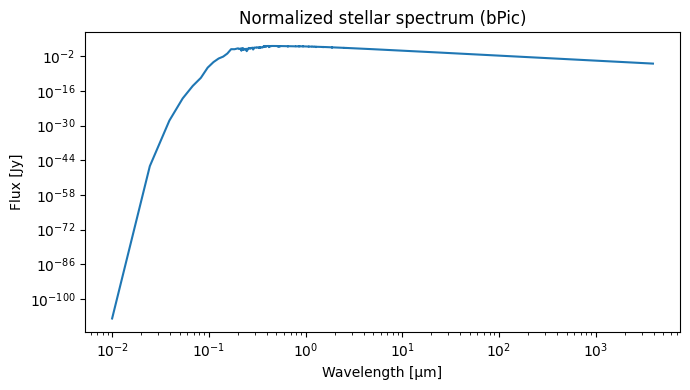

In [5]:
plt.figure(figsize=(7,4))
plt.loglog(star.waves, star.flux, c='tab:blue')
plt.xlabel('Wavelength [µm]')
plt.ylabel('Flux [Jy]')
plt.title('Normalized stellar spectrum (bPic)')
plt.tight_layout()

## 4. Resample / restrict wavelength range
You can request a different sampling by calling `get_spectra()` again.
Example: restrict to 0.4–5 µm with 1500 points.

In [ ]:
star.get_spectra(N_waves=1500, min_wave=0.4, max_wave=5.0, norm=True)
plt.figure(figsize=(7,4))
plt.loglog(star.waves, star.flux, c='tab:orange')
plt.xlabel('Wavelength [µm]')
plt.ylabel('Flux [Jy]')
plt.title('Resampled spectrum (0.4–5 µm)')
plt.tight_layout()

## 5. Compare two samplings
Instantiate a second star to show difference vs original full coverage.

In [ ]:
star_full = stgr.Star('bPic')
plt.figure(figsize=(7,4))
plt.loglog(star_full.waves, star_full.flux, label='Full', alpha=0.6)
plt.loglog(star.waves, star.flux, label='Restricted (0.4–5 µm)', alpha=0.8)
plt.xlabel('Wavelength [µm]')
plt.ylabel('Flux [Jy]')
plt.legend()
plt.title('Spectrum comparison')
plt.tight_layout()

## 6. Luminosity estimate
The `Star` object computes an approximate luminosity (in Lsun) after integrating the spectrum.

In [ ]:
print('Estimated luminosity [Lsun]:', star_full.lum)

## 7. Custom normalization (no magnitude scaling)
Call `get_spectra(..., norm=False)` to scale flux by geometric dilution only.

In [ ]:
star_geo = stgr.Star('bPic')
star_geo.get_spectra(N_waves=1000, norm=False)
plt.figure(figsize=(7,4))
plt.loglog(star_geo.waves, star_geo.flux, c='tab:green')
plt.xlabel('Wavelength [µm]')
plt.ylabel('Flux [Jy]')
plt.title('Geometrically scaled spectrum (no mag normalization)')
plt.tight_layout()

## 8. Summary
- `Star(name)` loads stellar properties and a synthetic spectrum
- Use `get_spectra()` to resample or restrict wavelength range
- Toggle `norm` for magnitude-based normalization vs geometric scaling
- Access: `star.waves`, `star.flux`, `star.lum`, `star.temp`, `star.radius`, etc.